In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_PRML'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_PRML.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_PRML
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_PRML/3
    print("準備完了！このまま下のセルを実行できます。")

# 3.3 ベイズ線形回帰 (Bayesian Linear Regression)

本ノートブックでは、最尤推定や正則化の限界（過学習やハイパーパラメータ調整）を克服する**ベイズ線形回帰 (Bayesian Linear Regression)** を徹底的に学びます。
パラメータの事前分布と事後分布の解析的更新、逐次学習、予測分布の導出、そしてカーネル法への架け橋となる**等価カーネル (Equivalent Kernel)** の性質を、教科書の代表的な実験（**PRML Figure 3.7, 3.8, 3.10, 3.11**）とともに完全再現します。

## 3.3.1 パラメータの事後分布 (Parameter Distribution)

線形回帰モデルにおいて、重みパラメータ $\mathbf{w}$ に対する共役事前分布としてガウス分布を導入します：
$$ p(\mathbf{w}) = \mathcal{N}(\mathbf{w} | \mathbf{m}_0, \mathbf{S}_0) $$
簡略化のため、平均 0、分散 $\alpha^{-1}\mathbf{I}$ の等方ガウス事前分布を用います：
$$ p(\mathbf{w} | \alpha) = \mathcal{N}\left(\mathbf{w} \middle| \mathbf{0}, \alpha^{-1} \mathbf{I}\right) = \left( \frac{\alpha}{2\pi} \right)^{M/2} \exp\left( -\frac{\alpha}{2} \mathbf{w}^T \mathbf{w} \right) $$

データ $\mathbf{t} = (t_1, \dots, t_N)^T$ が与えられたときの尤度関数は
$$ p(\mathbf{t} | \mathbf{w}, \beta) = \prod_{n=1}^N \mathcal{N}(t_n | \mathbf{w}^T \boldsymbol{\phi}(\mathbf{x}_n), \beta^{-1}) = \left( \frac{\beta}{2\pi} \right)^{N/2} \exp\left( -\frac{\beta}{2} \sum_{n=1}^N \{t_n - \mathbf{w}^T \boldsymbol{\phi}(\mathbf{x}_n)\}^2 \right) $$
事前分布と尤度がいずれも $\mathbf{w}$ について二次形式（ガウス分布）であるため、事後分布も再びガウス分布となります：
$$ p(\mathbf{w} | \mathbf{t}) = \mathcal{N}(\mathbf{w} | \mathbf{m}_N, \mathbf{S}_N) $$
ここで
$$ \mathbf{S}_N^{-1} = \mathbf{S}_0^{-1} + \beta \mathbf{\Phi}^T \mathbf{\Phi} = \alpha \mathbf{I} + \beta \mathbf{\Phi}^T \mathbf{\Phi} $$
$$ \mathbf{m}_N = \mathbf{S}_N (\mathbf{S}_0^{-1} \mathbf{m}_0 + \beta \mathbf{\Phi}^T \mathbf{t}) = \beta \mathbf{S}_N \mathbf{\Phi}^T \mathbf{t} $$

対数事後分布を最大化する解（MAP推定解）は
$$ \ln p(\mathbf{w} | \mathbf{t}) = -\frac{\beta}{2} \sum_{n=1}^N \{t_n - \mathbf{w}^T \boldsymbol{\phi}(\mathbf{x}_n)\}^2 - \frac{\alpha}{2} \mathbf{w}^T \mathbf{w} + \text{const} $$
となり、正則化パラメータ $\lambda = \alpha / \beta$ とした Ridge 回帰の目的関数と厳密に一致します。

Plot saved to: result/fig3_7_bayesian_linear_regression.png


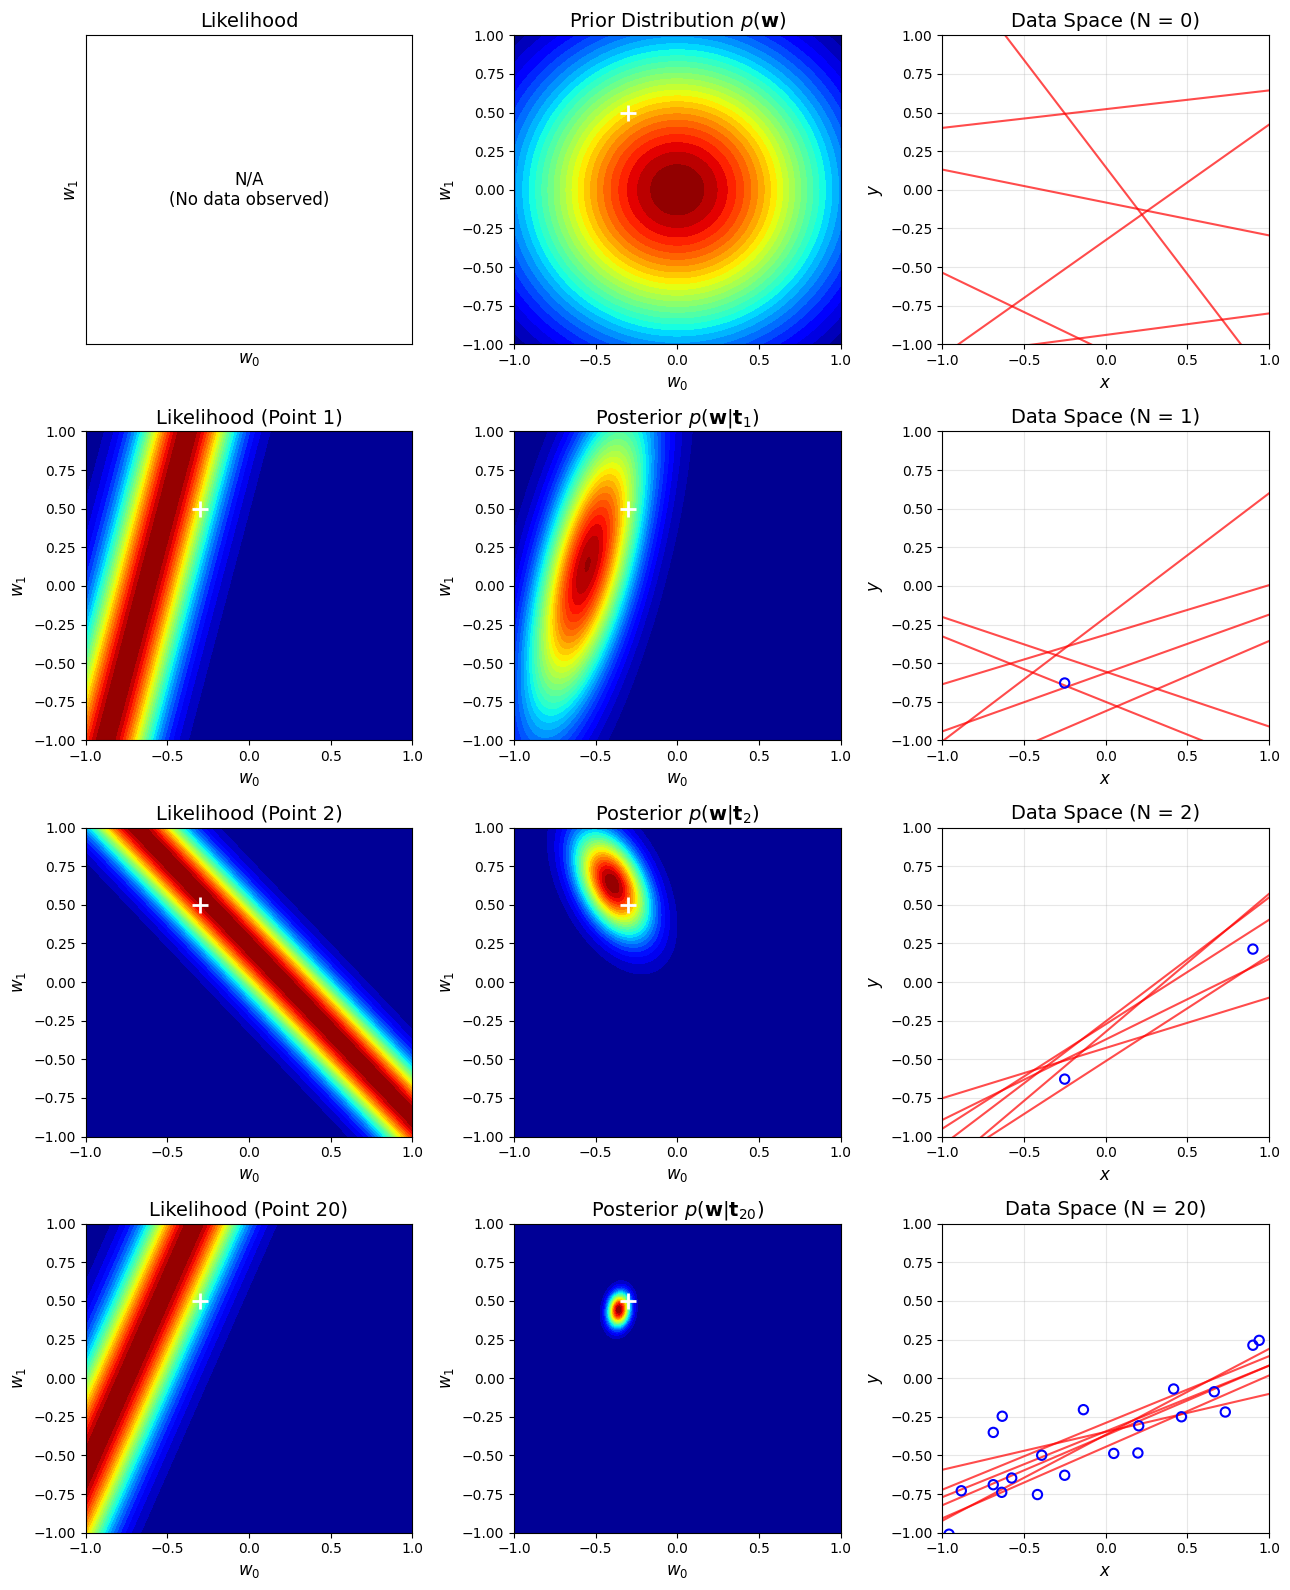

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from common.plot_utils import save_plot, setup_style
from common.regression_utils import BayesianLinearRegression, GaussianBasis
setup_style()

np.random.seed(42)

# PRML Figure 3.7 の実験設定
# 真の直線: y = -0.3 + 0.5 * x
a_0_true = -0.3
a_1_true = 0.5
beta = 25.0 # ノイズ精度 sigma = 0.2
alpha = 2.0 # 事前分布精度

# データ生成
N_points = 20
x_all = np.random.uniform(-1, 1, N_points)
t_all = a_0_true + a_1_true * x_all + np.random.normal(0, np.sqrt(1.0 / beta), N_points)

# パラメータ空間のグリッド
w0_grid = np.linspace(-1, 1, 150)
w1_grid = np.linspace(-1, 1, 150)
W0, W1 = np.meshgrid(w0_grid, w1_grid)
w_pos = np.dstack((W0, W1))

fig, axes = plt.subplots(4, 3, figsize=(13, 16))

# 各行に対応する観測データ数
stages = [0, 1, 2, 20]

for row_idx, N_seen in enumerate(stages):
    # 1. 尤度関数 (直近のデータ点に対する尤度)
    ax_like = axes[row_idx, 0]
    if N_seen == 0:
        ax_like.text(0.5, 0.5, 'N/A\n(No data observed)', ha='center', va='center', fontsize=12)
        ax_like.set_xticks([])
        ax_like.set_yticks([])
    else:
        # 直近の点 (x_last, t_last)
        x_last = x_all[N_seen - 1]
        t_last = t_all[N_seen - 1]
        # p(t | x, w) = N(t | w0 + w1*x, 1/beta)
        mean_pred = W0 + W1 * x_last
        likelihood = np.exp(-0.5 * beta * (t_last - mean_pred)**2)
        ax_like.contourf(W0, W1, likelihood, levels=30, cmap='jet')
        ax_like.plot(a_0_true, a_1_true, 'w+', markersize=12, markeredgewidth=2)
    ax_like.set_title(f'Likelihood (Point {N_seen})' if N_seen > 0 else 'Likelihood')
    ax_like.set_xlabel('$w_0$')
    ax_like.set_ylabel('$w_1$')

    # 2. 事後分布 (または事前分布)
    ax_post = axes[row_idx, 1]
    if N_seen == 0:
        # 事前分布 N(0, alpha^-1 I)
        prior_dist = stats.multivariate_normal([0, 0], (1.0 / alpha) * np.eye(2))
        Z = prior_dist.pdf(w_pos)
        m_curr = np.array([0.0, 0.0])
        S_curr = (1.0 / alpha) * np.eye(2)
        title = 'Prior Distribution $p(\mathbf{w})$'
    else:
        # N_seen 点までの事後分布
        Phi_sub = np.column_stack([np.ones(N_seen), x_all[:N_seen]])
        t_sub = t_all[:N_seen]
        blr = BayesianLinearRegression(alpha=alpha, beta=beta).fit(Phi_sub, t_sub)
        m_curr = blr.m_N
        S_curr = blr.S_N
        post_dist = stats.multivariate_normal(m_curr, S_curr)
        Z = post_dist.pdf(w_pos)
        title = f'Posterior $p(\mathbf{{w}}|\mathbf{{t}}_{{{N_seen}}})$'
        
    ax_post.contourf(W0, W1, Z, levels=30, cmap='jet')
    ax_post.plot(a_0_true, a_1_true, 'w+', markersize=12, markeredgewidth=2, label='True $\mathbf{w}^*$')
    ax_post.set_title(title)
    ax_post.set_xlabel('$w_0$')
    ax_post.set_ylabel('$w_1$')

    # 3. データ空間でのサンプル直線
    ax_data = axes[row_idx, 2]
    # 事後分布から 6 本のサンプルを生成
    w_samples = np.random.multivariate_normal(m_curr, S_curr, size=6)
    x_plot = np.linspace(-1, 1, 100)
    for w_s in w_samples:
        ax_data.plot(x_plot, w_s[0] + w_s[1] * x_plot, 'r-', alpha=0.7, lw=1.5)
        
    if N_seen > 0:
        ax_data.scatter(x_all[:N_seen], t_all[:N_seen], facecolors='none', edgecolors='blue', s=45, lw=1.5, zorder=5)
    ax_data.set_xlim(-1, 1)
    ax_data.set_ylim(-1, 1)
    ax_data.set_title(f'Data Space (N = {N_seen})')
    ax_data.set_xlabel('$x$')
    ax_data.set_ylabel('$y$')
    ax_data.grid(True, alpha=0.3)

plt.tight_layout()
save_plot(fig, 'result', 'fig3_7_bayesian_linear_regression.png')
plt.show()

## 3.3.2 予測分布 (Predictive Distribution)

新しい入力 $\mathbf{x}$ に対する目的変数 $t$ の予測は、重み $\mathbf{w}$ の事後分布に関して周辺化（積分消去）することで得られます：
$$ p(t | \mathbf{x}, \mathbf{t}, \alpha, \beta) = \int p(t | \mathbf{x}, \mathbf{w}, \beta) p(\mathbf{w} | \mathbf{t}, \alpha, \beta) d\mathbf{w} $$
線形ガウスモデルの公式（第2章 式 (2.115)）より、この積分は解析的に実行でき、再びガウス分布となります：
$$ p(t | \mathbf{x}, \mathbf{t}, \alpha, \beta) = \mathcal{N}(t | \mu_N(\mathbf{x}), \sigma_N^2(\mathbf{x})) $$
ここで
$$ \mu_N(\mathbf{x}) = \mathbf{m}_N^T \boldsymbol{\phi}(\mathbf{x}) $$
$$ \sigma_N^2(\mathbf{x}) = \frac{1}{\beta} + \boldsymbol{\phi}(\mathbf{x})^T \mathbf{S}_N \boldsymbol{\phi}(\mathbf{x}) $$
- 第1項 $\beta^{-1}$ は目的変数の内在的ノイズ（データ自体の不確実性）。
- 第2項 $\boldsymbol{\phi}(\mathbf{x})^T \mathbf{S}_N \boldsymbol{\phi}(\mathbf{x})$ はパラメータ $\mathbf{w}$ の不確実性に起因する分散。学習データが多くなるにつれて $\mathbf{S}_N \to \mathbf{0}$ となり、予測分散は $\beta^{-1}$ に漸近します。

Plot saved to: result/fig3_8_predictive_distribution.png


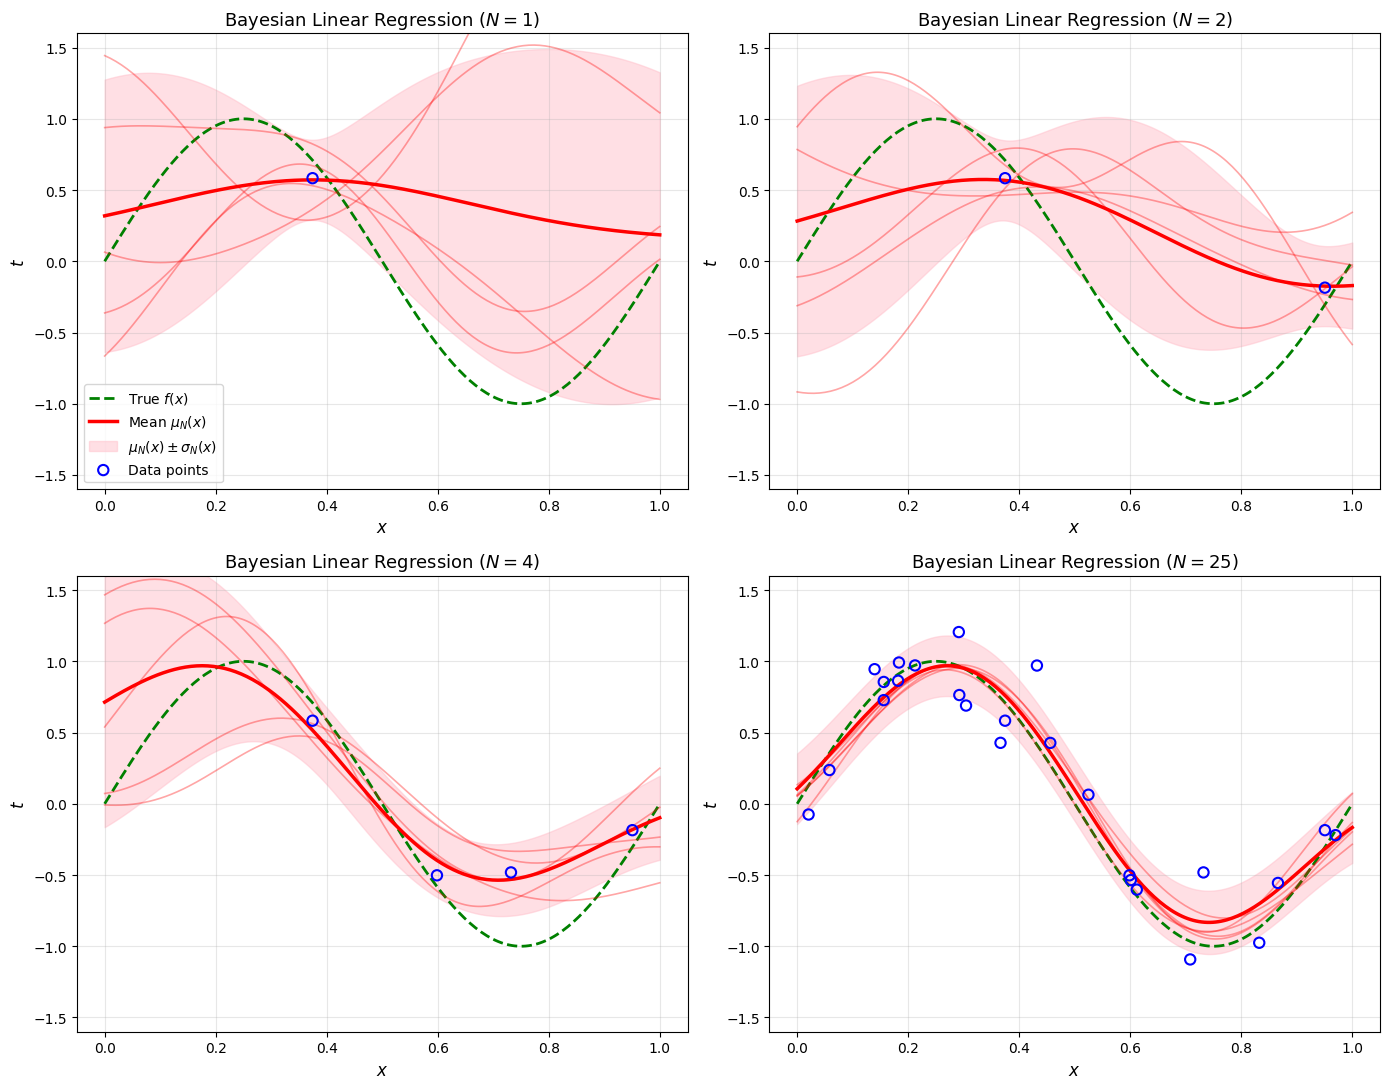

In [2]:
# PRML Figure 3.8 の再現: ガウス基底を用いた予測分布とサンプル関数
np.random.seed(42)

# 真の関数: sin(2 * pi * x)
def true_func(x):
    return np.sin(2 * np.pi * x)

N_max = 25
beta = 25.0 # sigma = 0.2
alpha = 2.0

x_train_8 = np.random.uniform(0, 1, N_max)
t_train_8 = true_func(x_train_8) + np.random.normal(0, np.sqrt(1.0 / beta), N_max)

# ガウス基底関数 M=9
centers = np.linspace(0, 1, 9)
scale = 0.2
basis = GaussianBasis(centers=centers, scale=scale)

x_eval = np.linspace(0, 1, 200)
Phi_eval = basis(x_eval)

subsets = [1, 2, 4, 25]
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for idx, N_sub in enumerate(subsets):
    ax = axes[idx]
    x_sub = x_train_8[:N_sub]
    t_sub = t_train_8[:N_sub]
    Phi_sub = basis(x_sub)
    
    blr = BayesianLinearRegression(alpha=alpha, beta=beta).fit(Phi_sub, t_sub)
    y_mean, y_std = blr.predict(Phi_eval)
    
    # 事後平均と +-1 標準偏差領域
    ax.plot(x_eval, true_func(x_eval), 'g--', lw=2, label=r'True $f(x)$')
    ax.plot(x_eval, y_mean, 'r-', lw=2.5, label=r'Mean $\mu_N(x)$')
    ax.fill_between(x_eval, y_mean - y_std, y_mean + y_std, color='pink', alpha=0.5, label=r'$\mu_N(x) \pm \sigma_N(x)$')
    
    # 事後分布からのサンプル関数 5本
    w_samples = blr.sample_weights(n_samples=5)
    for w_s in w_samples:
        y_sample = Phi_eval @ w_s
        ax.plot(x_eval, y_sample, 'r-', alpha=0.35, lw=1.2)
        
    ax.scatter(x_sub, t_sub, facecolors='none', edgecolors='b', s=55, lw=1.5, zorder=6, label='Data points')
    ax.set_ylim(-1.6, 1.6)
    ax.set_title(f'Bayesian Linear Regression ($N = {N_sub}$)', fontsize=13)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$t$')
    if idx == 0:
        ax.legend(loc='lower left', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
save_plot(fig, 'result', 'fig3_8_predictive_distribution.png')
plt.show()

## 3.3.3 等価カーネル (Equivalent Kernel)

予測分布の事後平均 $\mu_N(\mathbf{x})$ は、学習データセットの目標値 $t_n$ の線形結合として書き直すことができます：
$$ \mu_N(\mathbf{x}) = \mathbf{m}_N^T \boldsymbol{\phi}(\mathbf{x}) = \beta \boldsymbol{\phi}(\mathbf{x})^T \mathbf{S}_N \mathbf{\Phi}^T \mathbf{t} = \sum_{n=1}^N k(\mathbf{x}, \mathbf{x}_n) t_n $$
ここで
$$ k(\mathbf{x}, \mathbf{x}') = \beta \boldsymbol{\phi}(\mathbf{x})^T \mathbf{S}_N \boldsymbol{\phi}(\mathbf{x}') $$
は**等価カーネル (Equivalent Kernel)** と呼ばれます。

### 等価カーネルの重要な性質
1. **局在性 (Locality)**:
   $k(\mathbf{x}, \mathbf{x}')$ は $\mathbf{x}$ と $\mathbf{x}'$ が近いときに大きな正の値を持ち、離れると急速に減衰します。すなわち、新しい点 $\mathbf{x}$ における予測は近傍の目標値 $t_n$ の局所重み付き平均です。
2. **総和制約**:
   基底関数にバイアス項 $\phi_0(\mathbf{x})=1$ が含まれるとき、任意の $\mathbf{x}$ について以下を満たします：
   $$ \sum_{n=1}^N k(\mathbf{x}, \mathbf{x}_n) = 1 $$
3. **共分散との関係**:
   異なる2点でのモデル予測値の共分散は等価カーネルに比例します：
   $$ \mathrm{cov}[y(\mathbf{x}), y(\mathbf{x}')] = \boldsymbol{\phi}(\mathbf{x})^T \mathbf{S}_N \boldsymbol{\phi}(\mathbf{x}') = \frac{1}{\beta} k(\mathbf{x}, \mathbf{x}') $$

Plot saved to: result/fig3_10_11_equivalent_kernel.png


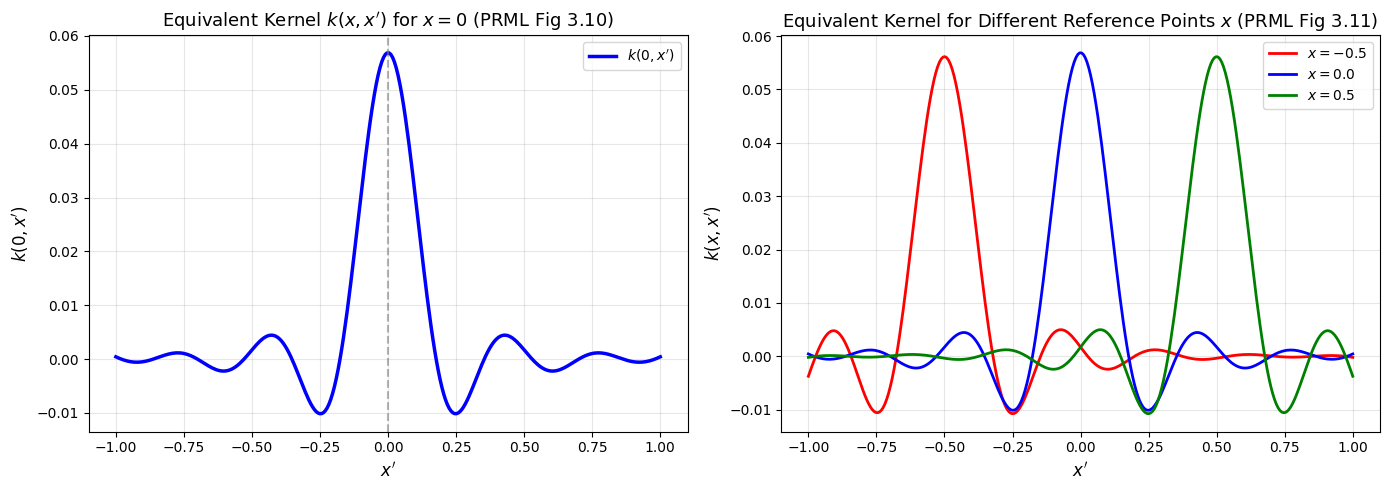

In [3]:
# PRML Figure 3.10 & Figure 3.11 の再現
# 多項式基底とシグモイド基底における等価カーネルの形状
x_support = np.linspace(-1, 1, 200)

# ガウス基底
centers_k = np.linspace(-1, 1, 15)
basis_g = GaussianBasis(centers=centers_k, scale=0.15)
Phi_supp_g = basis_g(x_support)

blr_k = BayesianLinearRegression(alpha=2.0, beta=25.0)
# 擬似データでフィッティング
blr_k.fit(Phi_supp_g, np.zeros(len(x_support)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fig 3.10: 等価カーネル k(x, x') の形状 (x = 0 に対する k(0, x'))
x_prime = np.linspace(-1, 1, 300)
Phi_prime = basis_g(x_prime)
Phi_zero = basis_g([0.0])

k_zero = blr_k.equivalent_kernel(Phi_zero).flatten() # 与えられた x_support に対する重み
# 連続カーネル k(0, x') = beta * phi(0)^T S_N phi(x')
k_continuous = blr_k.beta * (Phi_zero @ blr_k.S_N @ Phi_prime.T).flatten()

axes[0].plot(x_prime, k_continuous, 'b-', lw=2.5, label=r'$k(0, x^\prime)$')
axes[0].set_title(r'Equivalent Kernel $k(x, x^\prime)$ for $x=0$ (PRML Fig 3.10)', fontsize=13)
axes[0].set_xlabel(r'$x^\prime$')
axes[0].set_ylabel(r'$k(0, x^\prime)$')
axes[0].axvline(0, color='gray', linestyle='--', alpha=0.6)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Fig 3.11: 3つの異なる点 x = -0.5, 0.0, 0.5 に対するカーネル
x_refs = [-0.5, 0.0, 0.5]
colors = ['red', 'blue', 'green']
for x_r, col in zip(x_refs, colors):
    Phi_r = basis_g([x_r])
    k_r = blr_k.beta * (Phi_r @ blr_k.S_N @ Phi_prime.T).flatten()
    axes[1].plot(x_prime, k_r, color=col, lw=2, label=rf'$x = {x_r}$')

axes[1].set_title('Equivalent Kernel for Different Reference Points $x$ (PRML Fig 3.11)', fontsize=13)
axes[1].set_xlabel(r'$x^\prime$')
axes[1].set_ylabel(r'$k(x, x^\prime)$')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
save_plot(fig, 'result', 'fig3_10_11_equivalent_kernel.png')
plt.show()